In [1]:
import numpy as np
import scipy.constants
import scipy.sparse
from scipy.stats import norm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xarray as xr
import math
import geopandas as gpd
import pandas as pd
import os
import netCDF4 as nc
from scipy.ndimage import gaussian_filter1d

In [2]:
def calc_alongshore_transport_k(gravity=scipy.constants.g, n=1.0, rho_water=1050.0, gamma_b=0.78, ):
    return (
        5.3e-6
        # * 0.46
        * rho_water
        * gravity**1.5
        * (1 / (2 * n)) ** 1.2
        * (np.sqrt(gravity * gamma_b) / (2 * np.pi)) ** 0.2
    )

In [3]:
def get_angles_xr(x,y):

    ''' Takes average latitude and longitude calculated in beahc_w_to_gps.ipynb and computes bearing using bearing formula
    \(\theta =\>\mathrm{atan2}\>(\sin \Delta \lambda \cdot \cos \phi _{2},\cos \phi _{1}\cdot \sin \phi _{2}-\sin \phi _{1}\cdot \cos \phi _{2}\cdot \cos \Delta \lambda )\)'''
    
    lat = np.radians(y)
    lon = np.radians(x)
    lat1 = lat.shift(site=1)
    lon1 = lon.shift(site=1)
    lat2 = lat.shift(site=-1)
    lon2 = lon.shift(site=-1)
    dlon = lon2 - lon1  
    y = np.sin(dlon) * np.cos(lat2)
    x = np.cos(lat1) * np.sin(lat2) - np.sin(lat1) * np.cos(lat2) * np.cos(dlon)
    bearing = np.degrees(np.arctan2(y, x))
    bearing = (bearing + 360) % 360
    return bearing.fillna(0)

In [4]:
def calc_diff(dp, hs, tp, angles, k, d=8): # mean direction of propagation bearing from north (degrees), significant wave height (meters), period (seconds), k, d (meters) 

    '''Calculates diffusivity (mu) using formula from Ashton, Murray 2006 B, equation (8).'''
    
    # change to data array just in case
    tp_da = tp['tp'] if isinstance(tp, xr.Dataset) else tp
    hs_da = hs['hs'] if isinstance(hs, xr.Dataset) else hs
    dp_da = dp['dp'] if isinstance(dp, xr.Dataset) else dp

    # change angles to phi/theta and compute diffusivity 
    phi = dp_da - 90
    thet = ((angles + 90) % 360) - 90 # assumes no shoreline bearing angles greater than 270
    angle_term = ((phi - thet + 180) % 360) - 180
    angle_term = angle_term.where(np.abs(angle_term) <= 90)
    rad_factor = np.pi / 180
    angle_term = angle_term * rad_factor
    cos_term = np.cos(angle_term)
    sin_term = np.sin(angle_term)
    coeff = k / d
    power_term = ((tp_da * cos_term) ** 0.2) * (hs_da ** 2.4) 
    diff = -(coeff * power_term * ((1.2 * (sin_term**2)) - (cos_term**2)))
    return diff, angle_term

In [5]:
# open dataset
dp0 = xr.open_dataset('dp0_NorthCarolina.nc')
dp1 = xr.open_dataset('dp1_NorthCarolina.nc')
dp2 = xr.open_dataset('dp2_NorthCarolina.nc')
dp3 = xr.open_dataset('dp3_NorthCarolina.nc')
hs0 = xr.open_dataset('phs0_NorthCarolina.nc')
hs1 = xr.open_dataset('phs1_NorthCarolina.nc')
hs2 = xr.open_dataset('phs2_NorthCarolina.nc')
hs3 = xr.open_dataset('phs3_NorthCarolina.nc')
tp0 = xr.open_dataset('ptp0_NorthCarolina.nc')
tp1 = xr.open_dataset('ptp1_NorthCarolina.nc')
tp2 = xr.open_dataset('ptp2_NorthCarolina.nc')
tp3 = xr.open_dataset('ptp3_NorthCarolina.nc')
shore = xr.open_dataset('NC_average_lat_lon.nc')

In [6]:
# smooth shoreline
sigma = 50  # smoothing window, in units of points

x_smooth = gaussian_filter1d(shore['mean_lon'].values, sigma=sigma, mode='nearest')
y_smooth = gaussian_filter1d(shore['mean_lat'].values, sigma=sigma, mode='nearest')

shore = shore.assign(
    x_smooth=("site", x_smooth),
    y_smooth=("site", y_smooth),
)

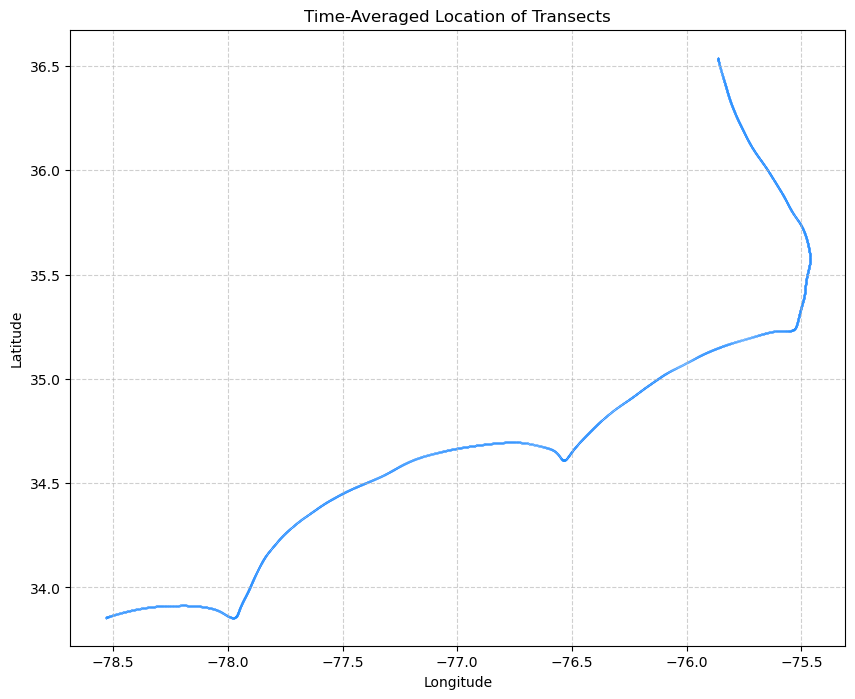

In [7]:
# plot shoreline points
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(
    shore['x_smooth'].values, 
    shore['y_smooth'].values, 
    s=.01, 
    c='dodgerblue', 
    alpha=0.7
)

ax.set_title('Time-Averaged Location of Transects')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, linestyle='--', alpha=0.6)

In [8]:
# compute shoreline angles (bearing from north)
angles_xr = get_angles_xr(shore['x_smooth'],shore['y_smooth'])

In [9]:
# extends and maps wave data to nearest transect centroid
wave_lats = dp0.lat.values
wave_lons = dp0.lon.values
transect_lats = shore['y_smooth'].values
transect_lons = shore['x_smooth'].values

def get_nearest_indices(w_lats, w_lons, t_lats, t_lons):
    indices = []
    for lat, lon in zip(t_lats, t_lons):
        dist = np.sqrt((w_lats - lat)**2 + (w_lons - lon)**2)
        indices.append(np.argmin(dist))
    return np.array(indices)

mapping_idx = get_nearest_indices(wave_lats, wave_lons, transect_lats, transect_lons)

dp0_mapped = dp0.isel(site=mapping_idx).assign_coords(
    site=shore.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

dp1_mapped = dp1.isel(site=mapping_idx).assign_coords(
    site=shore.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

dp2_mapped = dp2.isel(site=mapping_idx).assign_coords(
    site=shore.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

dp3_mapped = dp3.isel(site=mapping_idx).assign_coords(
    site=shore.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

hs0_mapped = hs0.isel(site=mapping_idx).assign_coords(
    site=shore.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

hs1_mapped = hs1.isel(site=mapping_idx).assign_coords(
    site=shore.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

hs2_mapped = hs2.isel(site=mapping_idx).assign_coords(
    site=shore.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

hs3_mapped = hs3.isel(site=mapping_idx).assign_coords(
    site=shore.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

tp0_mapped = tp0.isel(site=mapping_idx).assign_coords(
    site=shore.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

tp1_mapped = tp1.isel(site=mapping_idx).assign_coords(
    site=shore.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

tp2_mapped = tp2.isel(site=mapping_idx).assign_coords(
    site=shore.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

tp3_mapped = tp3.isel(site=mapping_idx).assign_coords(
    site=shore.site.values, 
    lat=("site", transect_lats), 
    lon=("site", transect_lons)
)

In [10]:
# iteratively save 4 .nc files
dps = {
    0: dp0_mapped,
    1: dp1_mapped,
    2: dp2_mapped,
    3: dp3_mapped 
}

hss = {
    0: hs0_mapped,
    1: hs1_mapped,
    2: hs2_mapped,
    3: hs3_mapped
}

tps = {
    0: tp0_mapped,
    1: tp1_mapped,
    2: tp2_mapped,
    3: tp3_mapped
}

k = calc_alongshore_transport_k()

for i in range(4):  
    file_name = f'ncmu{i}_hourly_pertransect.nc'
    
    if os.path.exists(file_name):
        os.remove(file_name)

    dp_curr = dps[i]
    hs_curr = hss[i]
    tp_curr = tps[i]
    
    total_time_len = len(dp_curr.time)

    full_template = xr.Dataset(
        data_vars={
            "mu": (("time", "site"), np.zeros((total_time_len, len(angles_xr)), dtype='float32')),
            "angle_diff": (("time", "site"), np.zeros((total_time_len, len(angles_xr)), dtype='float32')),
            "lat": ("site", shore['y_smooth'].values),
            "lon": ("site", shore['x_smooth'].values),
        },
        coords={"time": dp_curr.time, "site": dp_curr.site}
    )

    full_template.to_netcdf(file_name) 

    with nc.Dataset(file_name, 'a') as dst:
        step = 50000
        for start_idx in range(0, total_time_len, step):
            end_idx = min(start_idx + step, total_time_len)
            print(f"File {i} | Writing indices: {start_idx} to {end_idx}...")
            
            dp_slice = dp_curr.isel(time=slice(start_idx, end_idx))
            hs_slice = hs_curr.isel(time=slice(start_idx, end_idx))
            tp_slice = tp_curr.isel(time=slice(start_idx, end_idx))
            
            mu_slice, angle_slice = calc_diff(dp_slice, hs_slice, tp_slice, angles_xr, k)
    
            dst['mu'][start_idx:end_idx, :] = mu_slice.values
            dst['angle_diff'][start_idx:end_idx, :] = angle_slice.values
    
    print(f"Successfully saved {file_name}\n")

File 0 | Writing indices: 0 to 50000...
File 0 | Writing indices: 50000 to 100000...
File 0 | Writing indices: 100000 to 150000...
File 0 | Writing indices: 150000 to 200000...
File 0 | Writing indices: 200000 to 250000...
File 0 | Writing indices: 250000 to 300000...
File 0 | Writing indices: 300000 to 350000...
File 0 | Writing indices: 350000 to 385714...
Successfully saved ncmu0_hourly_pertransect.nc

File 1 | Writing indices: 0 to 50000...
File 1 | Writing indices: 50000 to 100000...
File 1 | Writing indices: 100000 to 150000...
File 1 | Writing indices: 150000 to 200000...
File 1 | Writing indices: 200000 to 250000...
File 1 | Writing indices: 250000 to 300000...
File 1 | Writing indices: 300000 to 350000...
File 1 | Writing indices: 350000 to 385714...
Successfully saved ncmu1_hourly_pertransect.nc

File 2 | Writing indices: 0 to 50000...
File 2 | Writing indices: 50000 to 100000...
File 2 | Writing indices: 100000 to 150000...
File 2 | Writing indices: 150000 to 200000...
File 